# arc.csv — Variance and Distribution by Experiment
This notebook loads `arc.csv` and shows per-experiment variance and distributions for each feature.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 120,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
})


In [58]:
split_config_path = 'config/data-split-config/train_test_split_each_setup_80.json'
split_config_path = 'config/data-split-config/train_test_split_based_on_column_gp3.json'

In [59]:
df = pd.read_csv('arc.csv')
df.head()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.0,22.145797,21.453291,0.031511,-0.523025
1,2,1.0,22.147194,21.507501,0.029108,-0.468815
2,2,2.0,22.146727,21.587299,0.025456,-0.389017
3,2,3.0,22.145979,21.664488,0.021910,-0.311828
4,2,4.0,22.147433,21.720590,0.019423,-0.255727


In [60]:
# Identify numeric feature columns (excluding Experiment_ID and angle column)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
angle_col = 'Angle[degree]ORDistance[mm]'
feature_cols = [c for c in numeric_cols if c not in ['Experiment_ID', angle_col]]
feature_cols

['Secondary-axis [mm]',
 'Main-axis [mm]',
 'Out-of-roundness [-]',
 'Collapse [mm]']

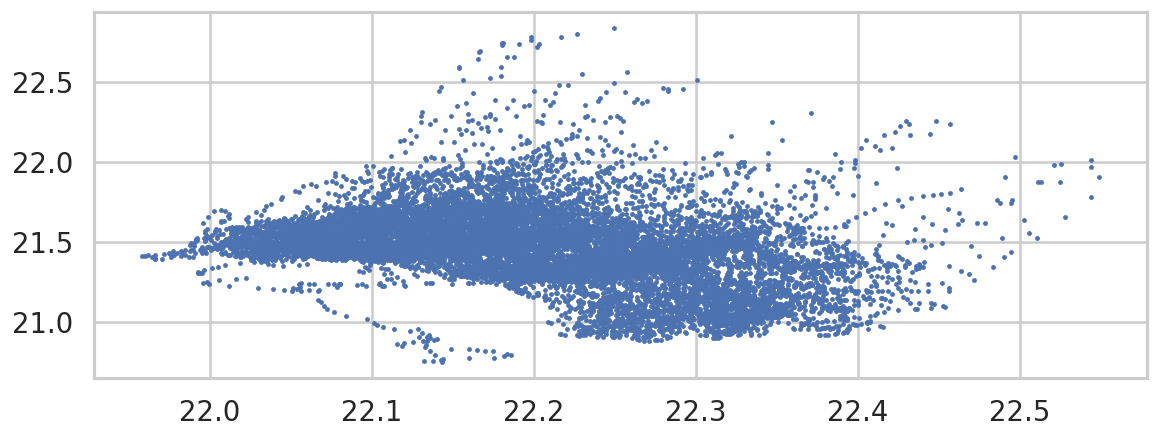

In [61]:
# Dual-axis plot: variance (left) + secondary metric (right)
# Update these feature names as needed
primary_feature = feature_cols[0]
secondary_feature = feature_cols[1] if len(feature_cols) > 1 else feature_cols[0]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.scatter(x= df[primary_feature], y= df[secondary_feature], s=2)

plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Dropdowns
exp_ids = sorted(df["Experiment_ID"].unique())

exp_dropdown = widgets.Dropdown(
    options=exp_ids,
    value=exp_ids[0],
    description="Experiment:",
)

x_dropdown = widgets.Dropdown(
    options=feature_cols,
    value=feature_cols[0],
    description="X feature:",
)

y_dropdown = widgets.Dropdown(
    options=feature_cols,
    value=feature_cols[1] if len(feature_cols) > 1 else feature_cols[0],
    description="Y feature:",
)

def plot_scatter(experiment_id, x_feature, y_feature):
    mask = df["Experiment_ID"] == experiment_id
    
    plt.figure(figsize=(10, 4))
    plt.scatter(df.loc[mask, x_feature], df.loc[mask, y_feature], s=2, alpha=0.6)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Experiment {experiment_id}: {x_feature} vs {y_feature}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ui = widgets.VBox([exp_dropdown, x_dropdown, y_dropdown])

out = widgets.interactive_output(
    plot_scatter,
    {
        "experiment_id": exp_dropdown,
        "x_feature": x_dropdown,
        "y_feature": y_dropdown,
    }
)

display(ui, out)


Output()

## Split helpers (set JSON path once and reuse)

In [27]:
import json

# Set your split config path here


def load_split_ids(split_config_path):
    with open(split_config_path, 'r') as f:
        split_cfg = json.load(f)
    train_ids = sorted({eid for group in split_cfg['train_groups'] for eid in group})
    test_ids = sorted({eid for group in split_cfg['test_groups'] for eid in group})
    return train_ids, test_ids

def plot_train_test_distributions(split_config_path, df, feature_cols, experiment_col='Experiment_ID'):
    train_ids, test_ids = load_split_ids(split_config_path)
    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    def plot_distributions(title, data):
        n = len(feature_cols)
        cols = 2
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(12, 4 * rows))
        for i, col in enumerate(feature_cols, 1):
            ax = plt.subplot(rows, cols, i)
            sns.histplot(data[col], kde=True, ax=ax, bins=30, color=sns.color_palette()[0], alpha=0.7)
            ax.set_title(f'{title}: {col}')
            ax.grid(True, alpha=0.2)
        sns.despine()
        plt.tight_layout()
        plt.show()

    plot_distributions('Train distribution', df_train)
    plot_distributions('Test distribution', df_test)

def plot_mean_std_by_angle_train_test(split_config_path, df, feature_cols, angle_col='Angle[degree]ORDistance[mm]', experiment_col='Experiment_ID'):
    train_ids, test_ids = load_split_ids(split_config_path)
    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    if angle_col not in df.columns:
        print(f'Angle column not found: {angle_col}')
        return

    mean_std_by_angle_train = df_train.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    mean_std_by_angle_test = df_test.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    display(mean_std_by_angle_train)
    display(mean_std_by_angle_test)

    train_color = sns.color_palette('deep')[0]
    test_color = sns.color_palette('deep')[2]

    for col in feature_cols:
        stats_train = df_train.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()
        stats_test = df_test.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()

        fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

        axes[0].plot(stats_train[angle_col], stats_train['mean'], color=train_color, label='train mean', linewidth=2)
        axes[0].fill_between(stats_train[angle_col], stats_train['mean']-stats_train['std'], stats_train['mean']+stats_train['std'], color=train_color, alpha=0.2)
        axes[0].set_title('Train')
        axes[0].set_xlabel(angle_col)
        axes[0].set_ylabel(col)
        axes[0].grid(True, alpha=0.2)
        axes[0].legend()

        axes[1].plot(stats_test[angle_col], stats_test['mean'], color=test_color, label='test mean', linewidth=2)
        axes[1].fill_between(stats_test[angle_col], stats_test['mean']-stats_test['std'], stats_test['mean']+stats_test['std'], color=test_color, alpha=0.2)
        axes[1].set_title('Test')
        axes[1].set_xlabel(angle_col)
        axes[1].grid(True, alpha=0.2)
        axes[1].legend()

        axes[2].plot(stats_train[angle_col], stats_train['mean'], color=train_color, label='train mean', linewidth=2)
        axes[2].fill_between(stats_train[angle_col], stats_train['mean']-stats_train['std'], stats_train['mean']+stats_train['std'], color=train_color, alpha=0.2)
        axes[2].plot(stats_test[angle_col], stats_test['mean'], color=test_color, label='test mean', linewidth=2)
        axes[2].fill_between(stats_test[angle_col], stats_test['mean']-stats_test['std'], stats_test['mean']+stats_test['std'], color=test_color, alpha=0.2)
        axes[2].set_title('Train vs Test')
        axes[2].set_xlabel(angle_col)
        axes[2].grid(True, alpha=0.2)
        axes[2].legend()

        fig.suptitle(f'{col}: mean ± std vs angle')
        fig.tight_layout()
        plt.show()


## Variance per experiment (by feature)

In [28]:
var_by_experiment = df.groupby('Experiment_ID')[feature_cols].var()
var_by_experiment

,Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
Experiment_ID,,,,
2,0.003598,0.017571,0.000015,0.017571
3,0.002385,0.020657,0.000024,0.020657
4,0.001513,0.019903,0.000027,0.019903
5,0.001983,0.019626,0.000025,0.019626
6,0.002020,0.014314,0.000017,0.014314
...,...,...,...,...
314,0.000383,0.016978,0.000036,0.016978
315,0.000229,0.016098,0.000036,0.016098
316,0.000143,0.016372,0.000035,0.016372


## Distributions (overall)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display

feature_selector = widgets.SelectMultiple(
    options=feature_cols,
    value=[feature_cols[0]],
    description="Features:",
    layout=widgets.Layout(width="50%", height="200px")
)

bins_slider = widgets.IntSlider(
    value=30, min=5, max=100, step=5,
    description="Bins:"
)

def plot_multi_hist(features, bins):
    if len(features) == 0:
        print("⚠️ Select at least one feature")
        return
    
    n = len(features)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i, col in enumerate(features, 1):
        ax = plt.subplot(rows, cols, i)
        sns.histplot(df[col], kde=True, ax=ax, bins=bins, alpha=0.7)
        ax.set_title(f"Distribution: {col}")
        ax.grid(True, alpha=0.2)

    sns.despine()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(
    plot_multi_hist,
    {"features": feature_selector, "bins": bins_slider}
)

display(widgets.VBox([feature_selector, bins_slider]), out)


Output()

## Distributions (train/test)

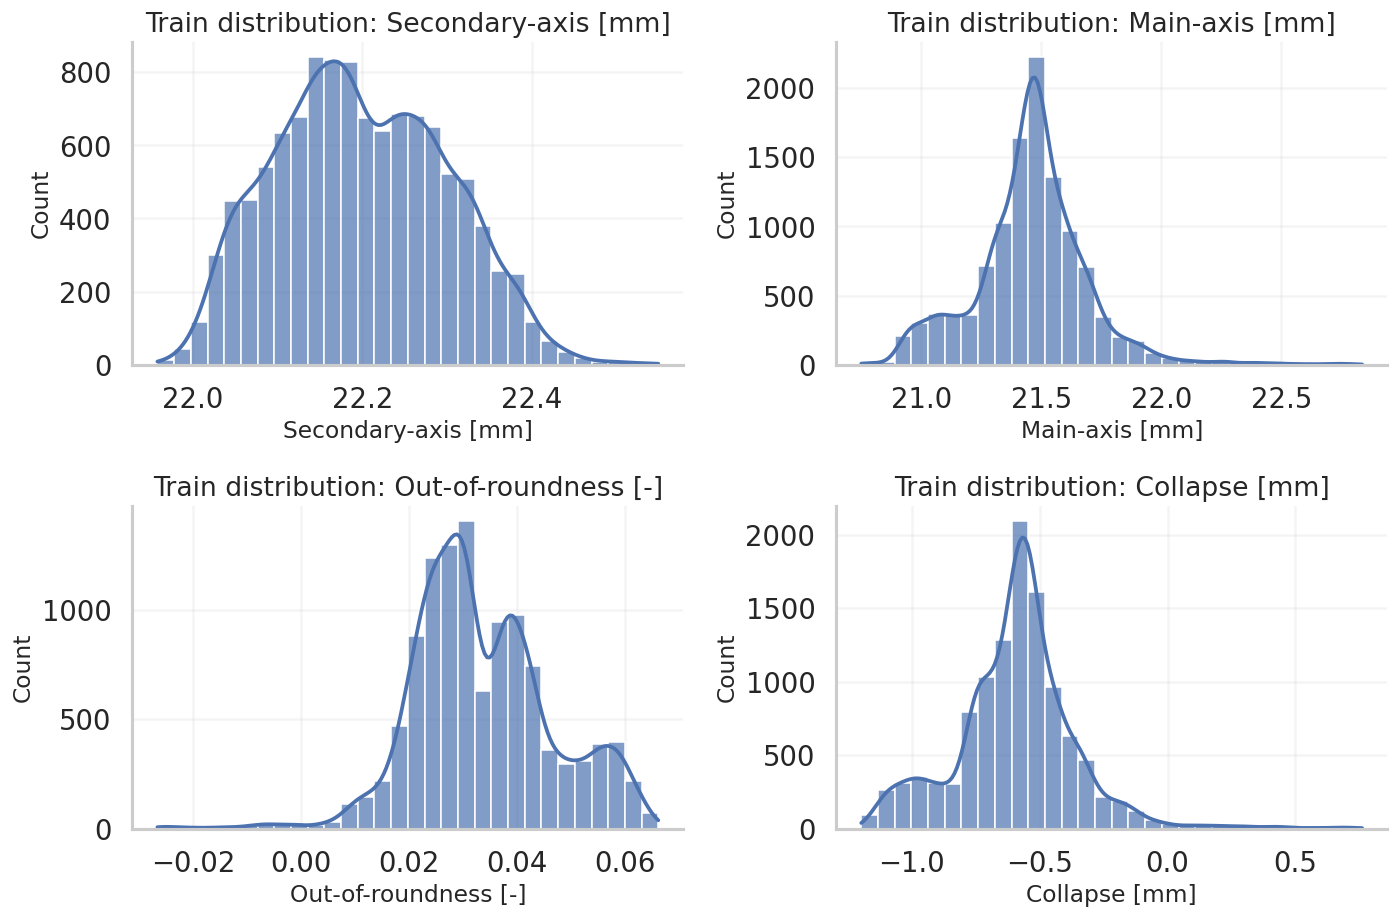

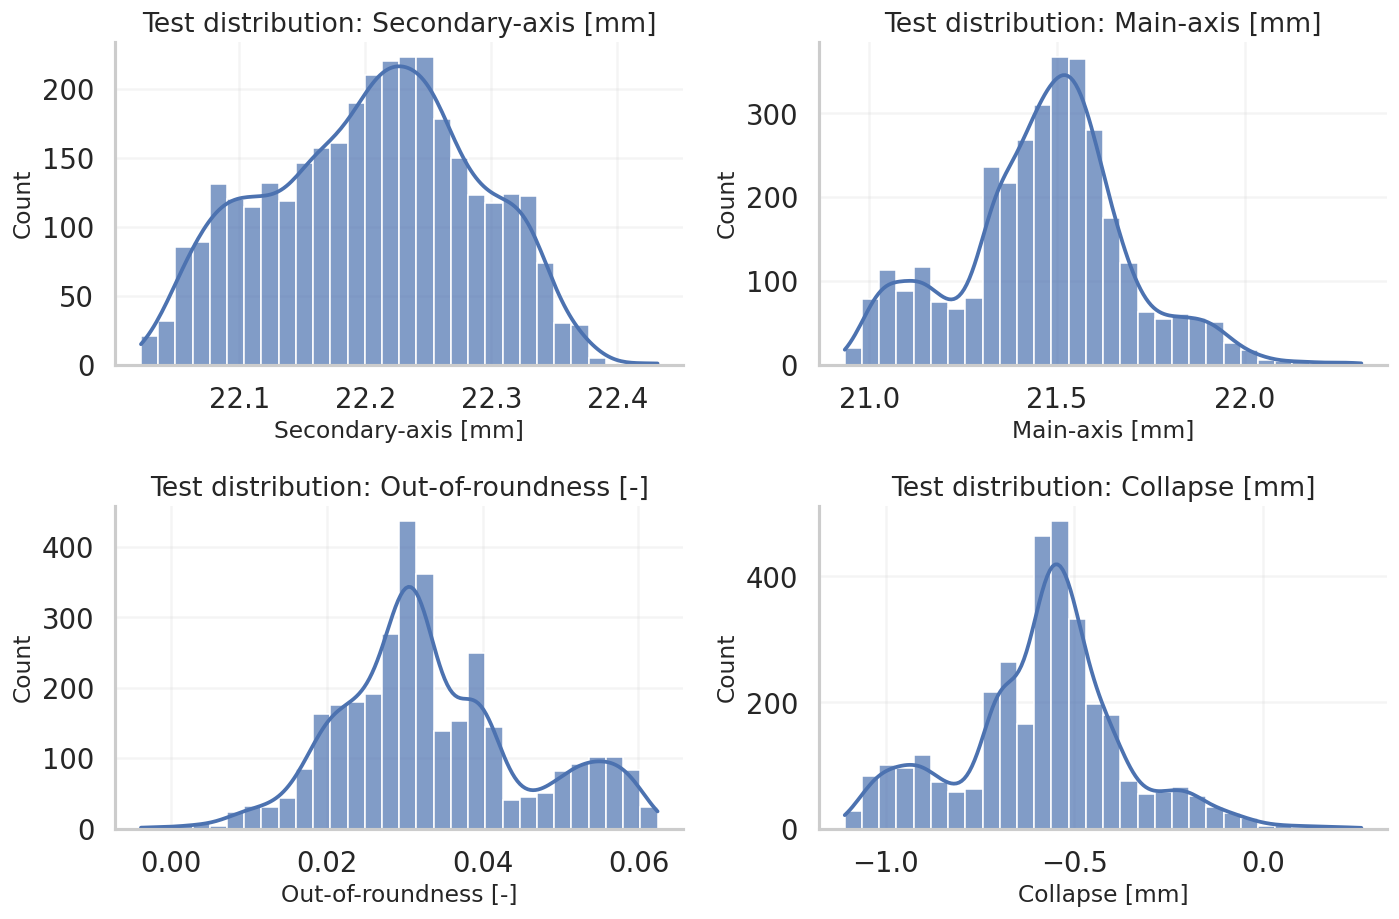

In [31]:
# Distributions for train and test splits
plot_train_test_distributions(split_config_path, df, feature_cols)

## Mean and std by angle (overall)

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.261140  0.089865      21.752891   
1.00                                  22.254268  0.090206      21.715828   
2.00                                  22.247717  0.089875      21.679114   
3.00                                  22.241209  0.089485      21.640354   
4.00                                  22.235010  0.089484      21.600134   
...                                         ...       ...            ...   
45.36                                 22.162477       NaN      21.637548   
45.37                                 22.088139       NaN      21.468084   
45.38                                 22.113138  0.063407      21.571097   
45.39                                 22.127244       NaN      21.597299   
45.42                                 22.118402       NaN      21.563877   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.353067             0.023049  0.017254   
1.00                         0.355211             0.024418  0.017712   
2.00                         0.350131             0.025786  0.017840   
3.00                         0.339625             0.027248  0.017673   
4.00                         0.325895             0.028791  0.017296   
...                               ...                  ...       ...   
45.36                             NaN             0.023778       NaN   
45.37                             NaN             0.028121       NaN   
45.38                        0.030934             0.024570  0.001420   
45.39                             NaN             0.024014       NaN   
45.42                             NaN             0.025145       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.298332  0.350074  
1.00                            -0.335395  0.352364  
2.00                            -0.372109  0.347516  
3.00                            -0.410869  0.337276  
4.00                            -0.451089  0.323839  
...                                   ...       ...  
45.36                           -0.438489       NaN  
45.37                           -0.581361       NaN  
45.38                           -0.489073  0.015571  
45.39                           -0.471240       NaN  
45.42                           -0.489674       NaN  

[109 rows x 8 columns]

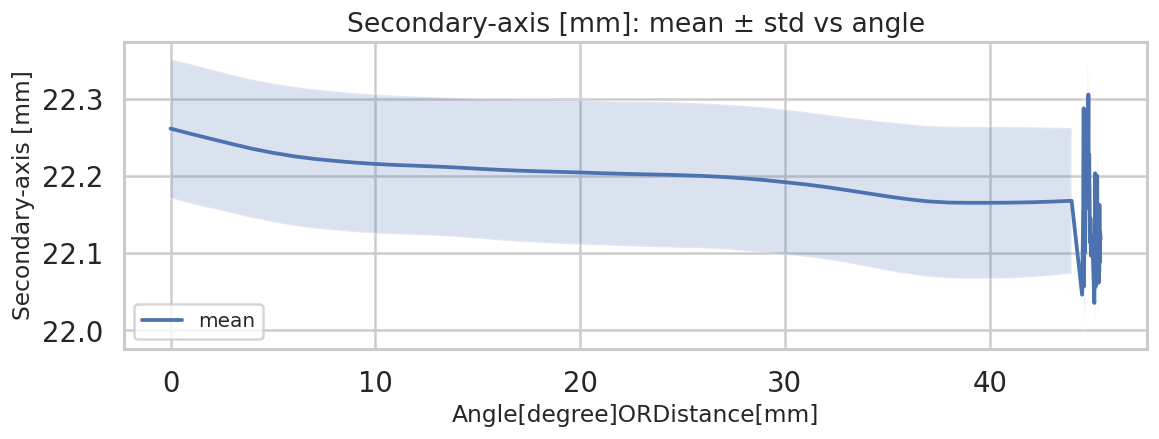

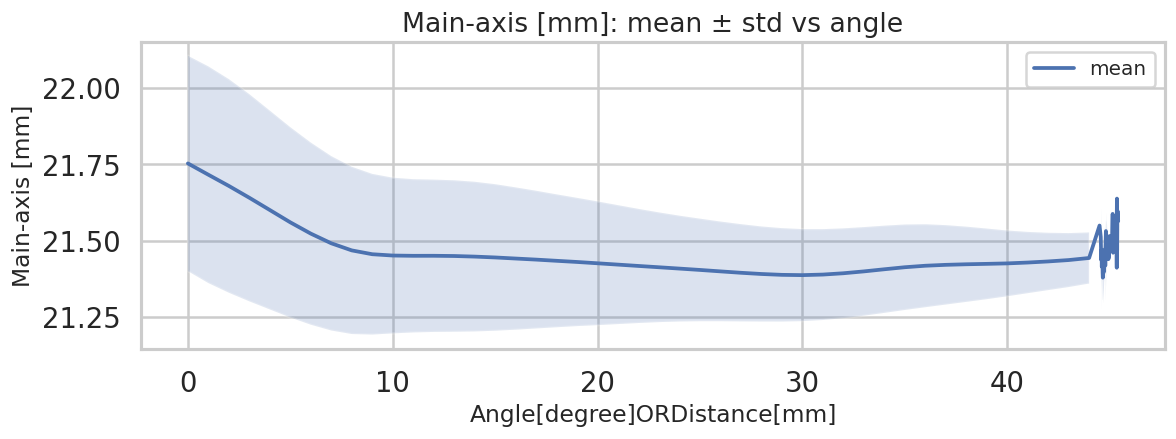

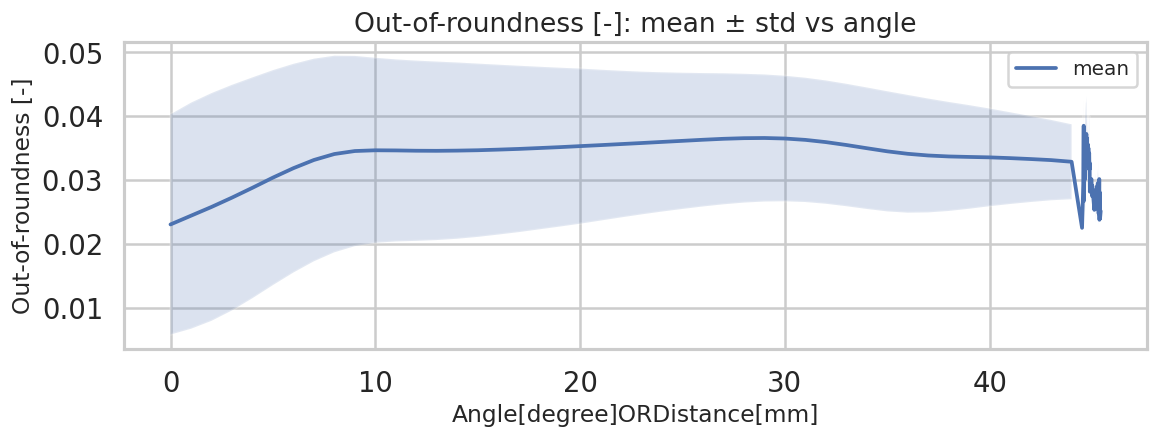

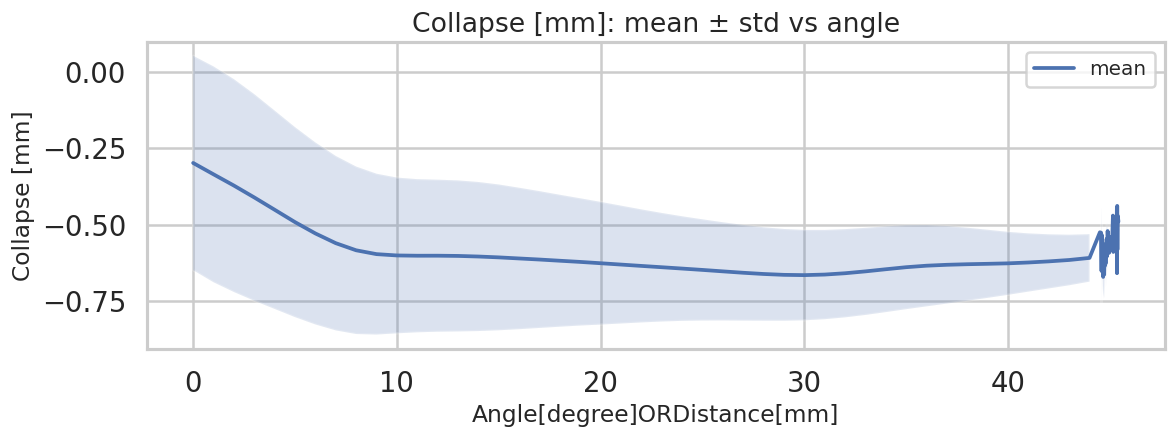

In [32]:
if angle_col in df.columns:
    mean_std_by_angle = df.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    display(mean_std_by_angle)

    for col in feature_cols:
        stats = df.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()
        plt.figure(figsize=(10, 4))
        plt.plot(stats[angle_col], stats['mean'], label='mean')
        plt.fill_between(stats[angle_col], stats['mean']-stats['std'], stats['mean']+stats['std'], alpha=0.2)
        plt.title(f'{col}: mean ± std vs angle')
        plt.xlabel(angle_col)
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print(f'Angle column not found: {angle_col}')


## Mean and std by angle (train/test split)

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.261303  0.096215      21.746473   
1.00                                  22.254477  0.096220      21.709376   
2.00                                  22.247950  0.095604      21.674040   
3.00                                  22.241483  0.094813      21.637262   
4.00                                  22.235323  0.094475      21.599381   
...                                         ...       ...            ...   
45.36                                 22.162477       NaN      21.637548   
45.37                                 22.088139       NaN      21.468084   
45.38                                 22.113138  0.063407      21.571097   
45.39                                 22.127244       NaN      21.597299   
45.42                                 22.118402       NaN      21.563877   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.364718             0.023348  0.017628   
1.00                         0.367113             0.024720  0.018139   
2.00                         0.361410             0.026026  0.018295   
3.00                         0.349437             0.027401  0.018127   
4.00                         0.333685             0.028839  0.017729   
...                               ...                  ...       ...   
45.36                             NaN             0.023778       NaN   
45.37                             NaN             0.028121       NaN   
45.38                        0.030934             0.024570  0.001420   
45.39                             NaN             0.024014       NaN   
45.42                             NaN             0.025145       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.304456  0.361858  
1.00                            -0.341552  0.364570  
2.00                            -0.376889  0.359344  
3.00                            -0.413666  0.347947  
4.00                            -0.451547  0.332846  
...                                   ...       ...  
45.36                           -0.438489       NaN  
45.37                           -0.581361       NaN  
45.38                           -0.489073  0.015571  
45.39                           -0.471240       NaN  
45.42                           -0.489674       NaN  

[104 rows x 8 columns]

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.260590  0.064509      21.774554   
1.00                                  22.253564  0.066558      21.737602   
2.00                                  22.246932  0.067594      21.696241   
3.00                                  22.240282  0.069084      21.650789   
4.00                                  22.233955  0.070634      21.602674   
...                                         ...       ...            ...   
45.28                                 22.165906  0.030713      21.487089   
45.30                                 22.101065  0.035397      21.471765   
45.31                                 22.176594       NaN      21.505224   
45.33                                 22.288487       NaN      21.537859   
45.34                                 22.123759       NaN      21.536642   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.311918             0.022042  0.016006   
1.00                         0.313093             0.023399  0.016265   
2.00                         0.310771             0.024974  0.016303   
3.00                         0.306238             0.026735  0.016158   
4.00                         0.300301             0.028630  0.015864   
...                               ...                  ...       ...   
45.28                        0.029687             0.030774  0.000024   
45.30                        0.010397             0.028561  0.001994   
45.31                             NaN             0.030428       NaN   
45.33                             NaN             0.033962       NaN   
45.34                             NaN             0.026609       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.277663  0.308416  
1.00                            -0.314615  0.309056  
2.00                            -0.355976  0.305990  
3.00                            -0.401428  0.300530  
4.00                            -0.449543  0.293571  
...                                   ...       ...  
45.28                           -0.570947  0.013409  
45.30                           -0.561701  0.019139  
45.31                           -0.559288       NaN  
45.33                           -0.564191       NaN  
45.34                           -0.528212       NaN  

[79 rows x 8 columns]

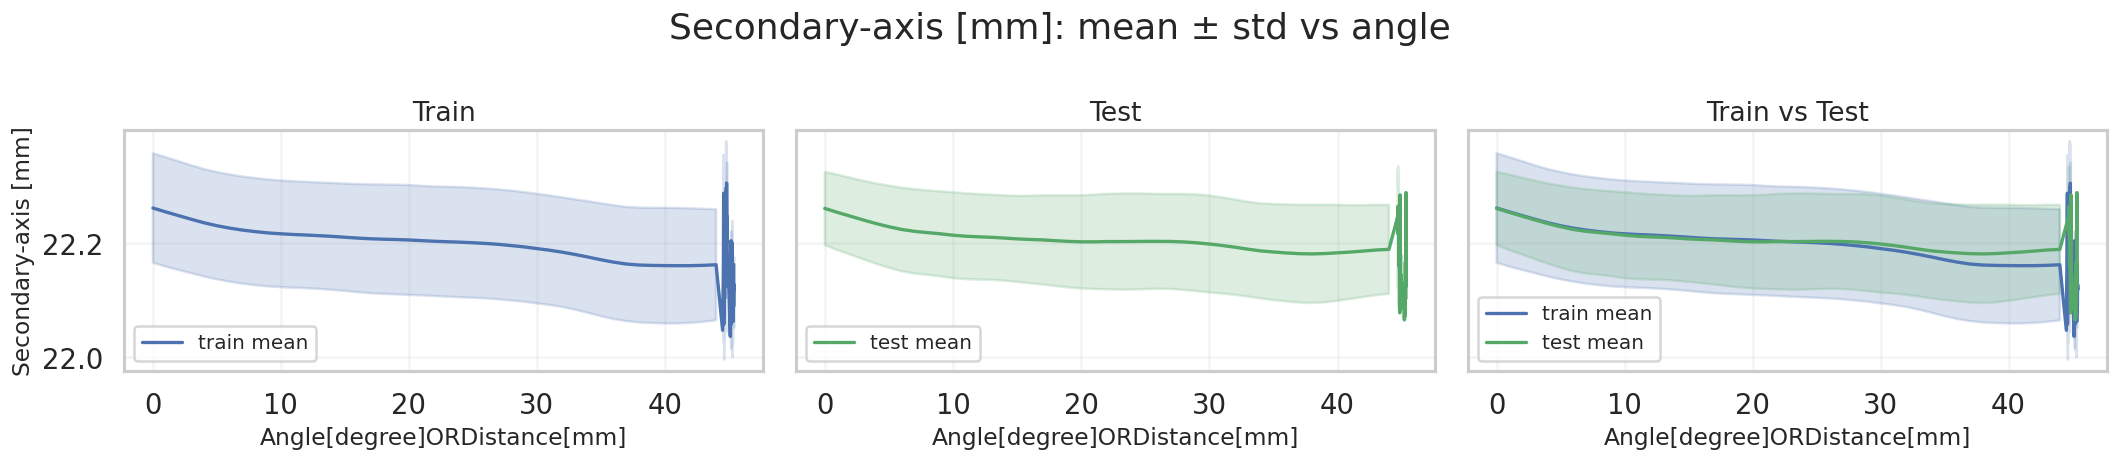

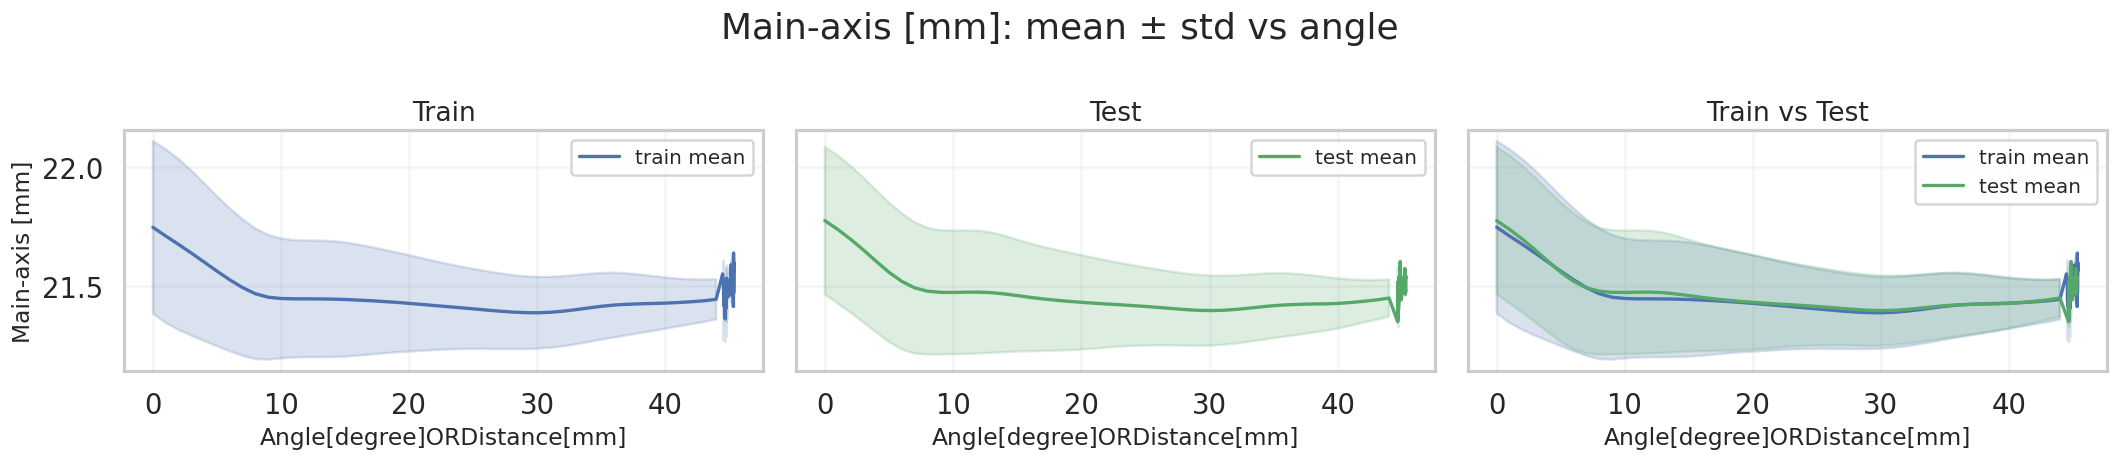

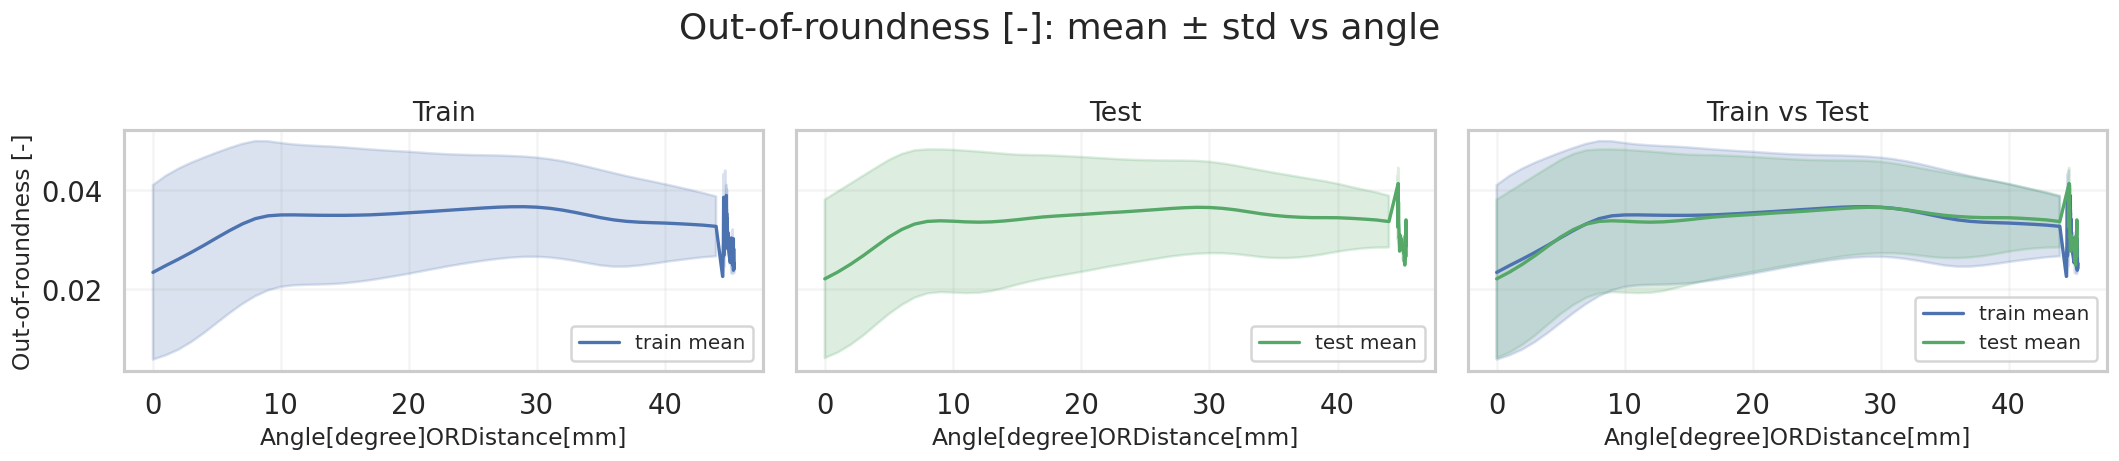

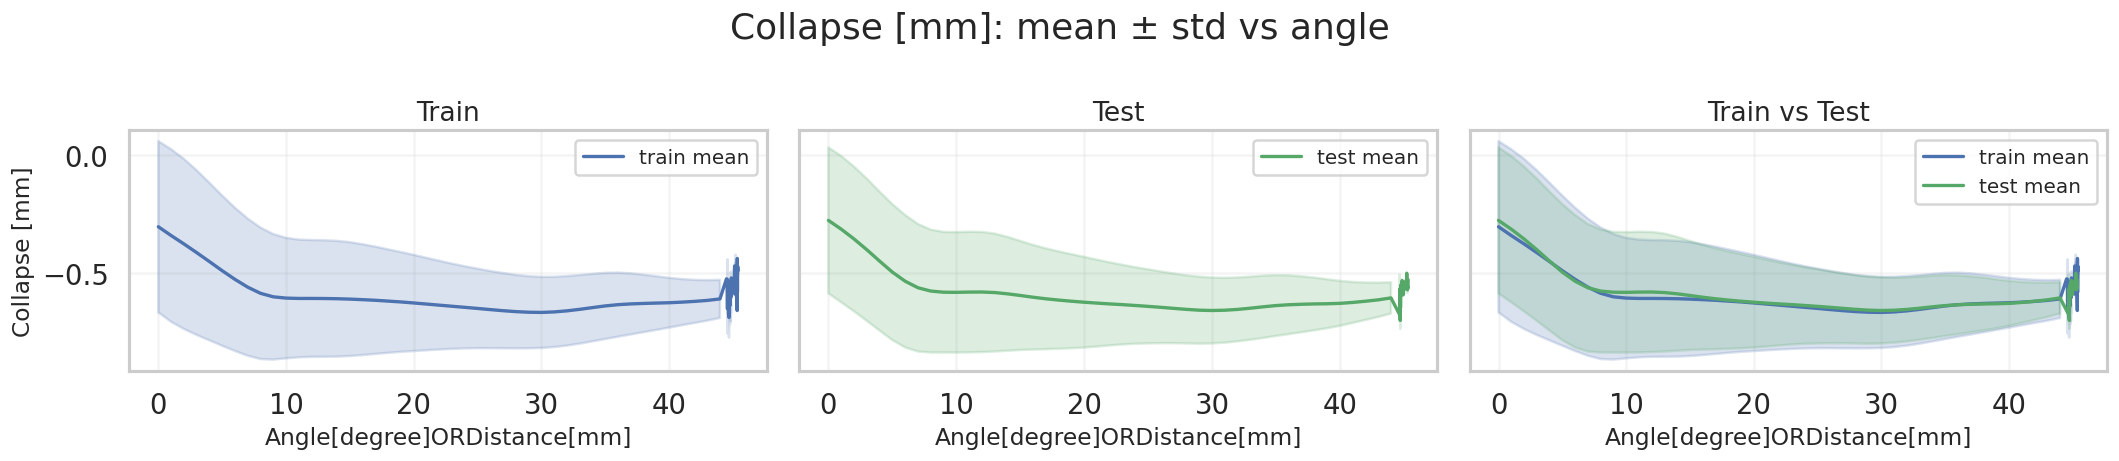

In [33]:
# Mean/std by angle for train and test splits
plot_mean_std_by_angle_train_test(split_config_path, df, feature_cols)